<a href="https://colab.research.google.com/github/TejasKayarkar03/Pattern-Recognition-Lab/blob/main/PR_CM23045_Pr8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install KaggleHub
!pip install -q kagglehub

import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)

# Download dataset
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Dataset path:", path)

# Show files
print(os.listdir(path))

TensorFlow version: 2.20.0
Using Colab cache for faster access to the 'intel-image-classification' dataset.
Dataset path: /kaggle/input/intel-image-classification
['seg_train', 'seg_pred', 'seg_test']


In [ ]:
# Check directory structure
for root, dirs, files in os.walk(path):
    print(root)
    if len(files) > 0:
        print("  Files:", len(files))
    if root.count(os.sep) - path.count(os.sep) >= 2:
        dirs[:] = []

/kaggle/input/intel-image-classification
/kaggle/input/intel-image-classification/seg_train
/kaggle/input/intel-image-classification/seg_train/seg_train
/kaggle/input/intel-image-classification/seg_pred
/kaggle/input/intel-image-classification/seg_pred/seg_pred
  Files: 7301
/kaggle/input/intel-image-classification/seg_test
/kaggle/input/intel-image-classification/seg_test/seg_test


In [ ]:
train_dir = os.path.join(path, "seg_train", "seg_train")
test_dir  = os.path.join(path, "seg_test", "seg_test")

print("Train directory:", train_dir)
print("Test directory:", test_dir)

print("Classes:", os.listdir(train_dir))

Train directory: /kaggle/input/intel-image-classification/seg_train/seg_train
Test directory: /kaggle/input/intel-image-classification/seg_test/seg_test
Classes: ['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']


In [ ]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6


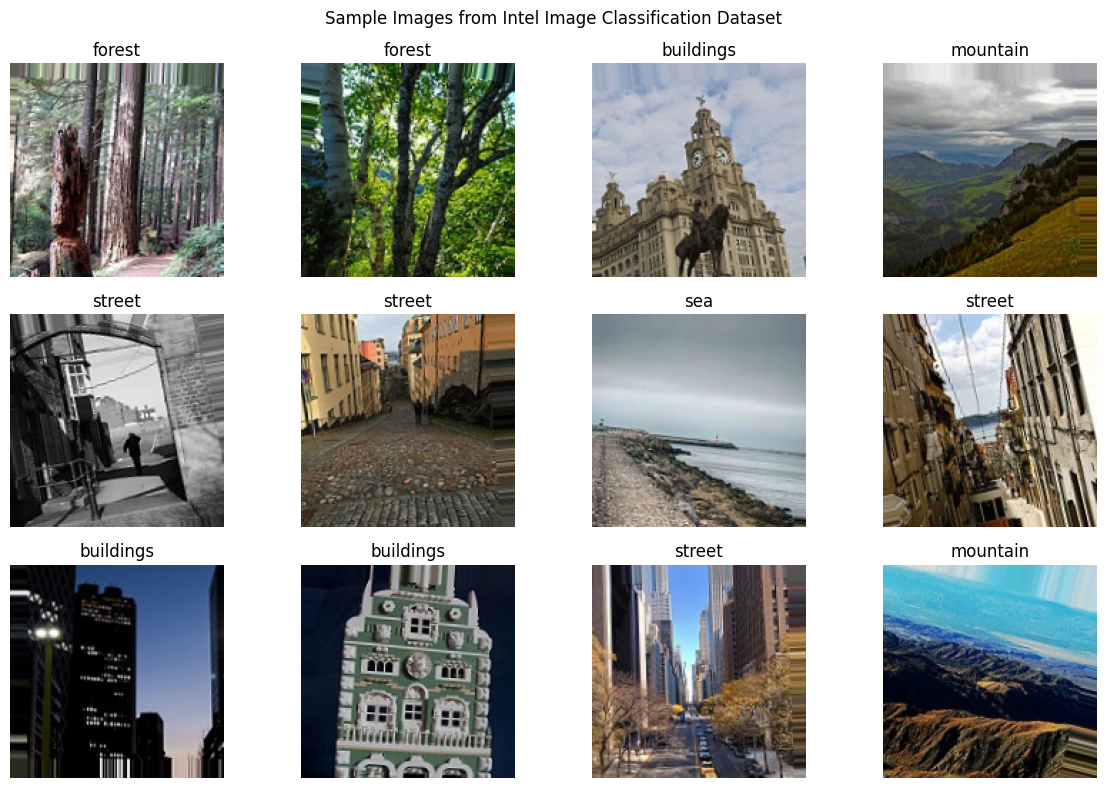

In [ ]:
images, labels = next(train_data)

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.suptitle("Sample Images from Intel Image Classification Dataset")
plt.tight_layout()
plt.show()

In [ ]:
cnn_model = models.Sequential([

    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Classification
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cnn = cnn_model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 661s 2s/step - accuracy: 0.5401 - loss: 1.1650 - val_accuracy: 0.6252 - val_loss: 0.9857
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 650s 2s/step - accuracy: 0.6542 - loss: 0.9138 - val_accuracy: 0.6512 - val_loss: 0.9576
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 667s 2s/step - accuracy: 0.7038 - loss: 0.8070 - val_accuracy: 0.7775 - val_loss: 0.6560
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 667s 2s/step - accuracy: 0.7386 - loss: 0.7293 - val_accuracy: 0.7682 - val_loss: 0.6574
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 648s 2s/step - accuracy: 0.7600 - loss: 0.6679 - val_accuracy: 0.8071 - val_loss: 0.5600
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 657s 2s/step - accuracy: 0.7901 - loss: 0.6107 - val_accuracy: 0.7821 - val_loss: 0.5826
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 673s 2s/step - accuracy: 0.7882 - loss: 0.5998 - val_accuracy: 0.8149 - val_loss: 0.5127
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 657s 2s/step - accuracy: 0.8002 - loss: 0.5637 - val_accu

In [ ]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(test_data)

print("CNN Test Loss:", cnn_loss)
print("CNN Test Accuracy:", cnn_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 45s 478ms/step - accuracy: 0.8480 - loss: 0.4378
CNN Test Loss: 0.4377973675727844
CNN Test Accuracy: 0.8479999899864197


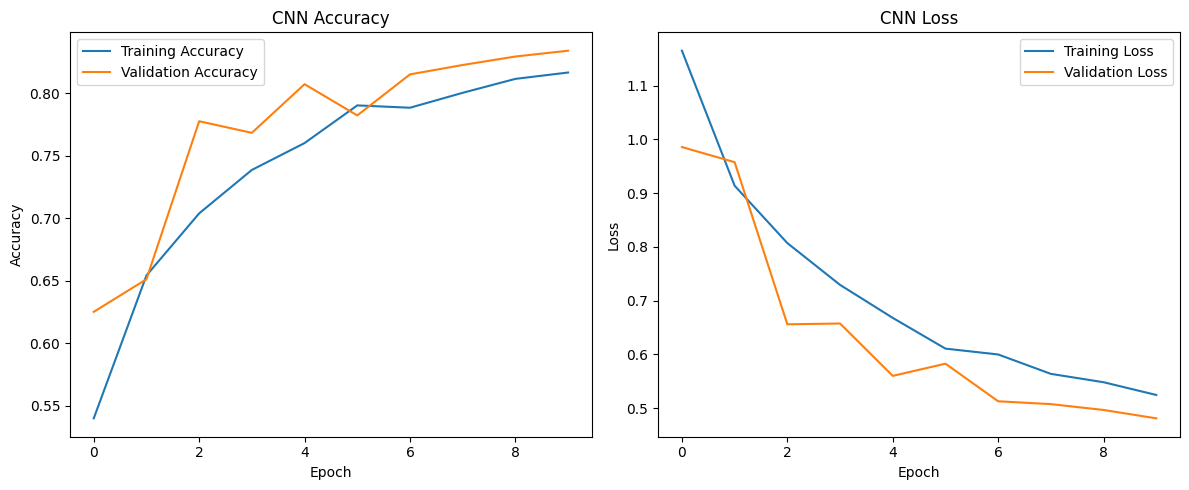

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)

plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_data.reset()

predictions = cnn_model.predict(test_data)

y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

print("CNN Classification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

94/94 ━━━━━━━━━━━━━━━━━━━━ 43s 454ms/step
CNN Classification Report:

              precision    recall  f1-score   support

   buildings       0.79      0.89      0.83       437
      forest       0.98      0.89      0.93       474
     glacier       0.79      0.85      0.82       553
    mountain       0.84      0.76      0.80       525
         sea       0.87      0.85      0.86       510
      street       0.85      0.87      0.86       501

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000



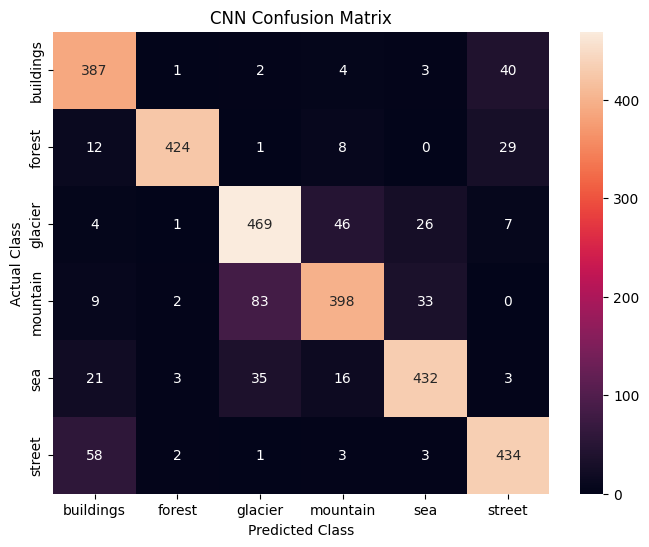

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("CNN Confusion Matrix")

plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [ ]:
mobile_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

mobile_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

mobile_train = mobile_train_datagen.flow_from_directory(
    train_dir,
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

mobile_validation = mobile_train_datagen.flow_from_directory(
    train_dir,
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

mobile_test = mobile_test_datagen.flow_from_directory(
    test_dir,
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(160, 160, 3)
)

# Freeze pretrained layers
base_model.trainable = False

mobile_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(6, activation='softmax')
])

mobile_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobile_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history_mobile = mobile_model.fit(
    mobile_train,
    validation_data=mobile_validation,
    epochs=10
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 388s 1s/step - accuracy: 0.8523 - loss: 0.4018 - val_accuracy: 0.9037 - val_loss: 0.2724
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 378s 1s/step - accuracy: 0.8927 - loss: 0.2965 - val_accuracy: 0.9094 - val_loss: 0.2537
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.9022 - loss: 0.2664 - val_accuracy: 0.9141 - val_loss: 0.2417
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 383s 1s/step - accuracy: 0.9077 - loss: 0.2491 - val_accuracy: 0.9130 - val_loss: 0.2531
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 379s 1s/step - accuracy: 0.9128 - loss: 0.2363 - val_accuracy: 0.9005 - val_loss: 0.2570
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 379s 1s/step - accuracy: 0.9166 - loss: 0.2209 - val_accuracy: 0.9062 - val_loss: 0.2620
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.9161 - loss: 0.2184 - val_accuracy: 0.9123 - val_loss: 0.2513
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 377s 1s/step - accuracy: 0.9209 - loss: 0.2131 - val_accu

In [ ]:
mobile_loss, mobile_accuracy = mobile_model.evaluate(mobile_test)

print("MobileNetV2 Test Loss:", mobile_loss)
print("MobileNetV2 Test Accuracy:", mobile_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 63s 669ms/step - accuracy: 0.9127 - loss: 0.2249
MobileNetV2 Test Loss: 0.22491160035133362
MobileNetV2 Test Accuracy: 0.9126666784286499


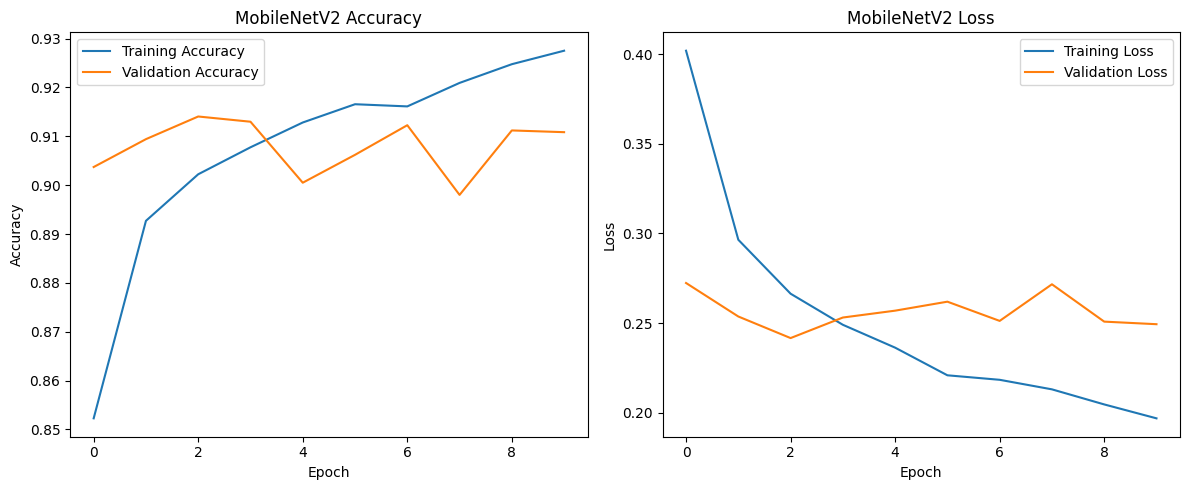

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(
    history_mobile.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_mobile.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)

plt.plot(
    history_mobile.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_mobile.history['val_loss'],
    label='Validation Loss'
)

plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
mobile_test.reset()

mobile_predictions = mobile_model.predict(mobile_test)

mobile_y_pred = np.argmax(mobile_predictions, axis=1)
mobile_y_true = mobile_test.classes

print("MobileNetV2 Classification Report:\n")

print(classification_report(
    mobile_y_true,
    mobile_y_pred,
    target_names=class_names
))

94/94 ━━━━━━━━━━━━━━━━━━━━ 66s 689ms/step
MobileNetV2 Classification Report:

              precision    recall  f1-score   support

   buildings       0.93      0.89      0.91       437
      forest       0.99      0.99      0.99       474
     glacier       0.89      0.80      0.84       553
    mountain       0.83      0.90      0.87       525
         sea       0.95      0.96      0.95       510
      street       0.90      0.95      0.93       501

    accuracy                           0.91      3000
   macro avg       0.92      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



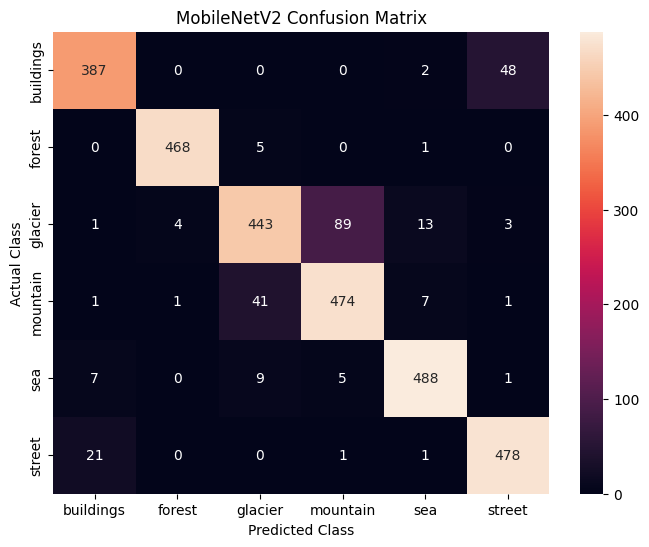

In [ ]:
cm_mobile = confusion_matrix(
    mobile_y_true,
    mobile_y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_mobile,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("MobileNetV2 Confusion Matrix")

plt.show()

In [ ]:
print("\n========== MODEL COMPARISON ==========")

print(f"CNN Accuracy        : {cnn_accuracy * 100:.2f}%")
print(f"MobileNetV2 Accuracy: {mobile_accuracy * 100:.2f}%")

if mobile_accuracy > cnn_accuracy:
    print("\nMobileNetV2 performs better.")
else:
    print("\nCNN performs better.")


========== MODEL COMPARISON ==========
CNN Accuracy        : 84.80%
MobileNetV2 Accuracy: 91.27%

MobileNetV2 performs better.


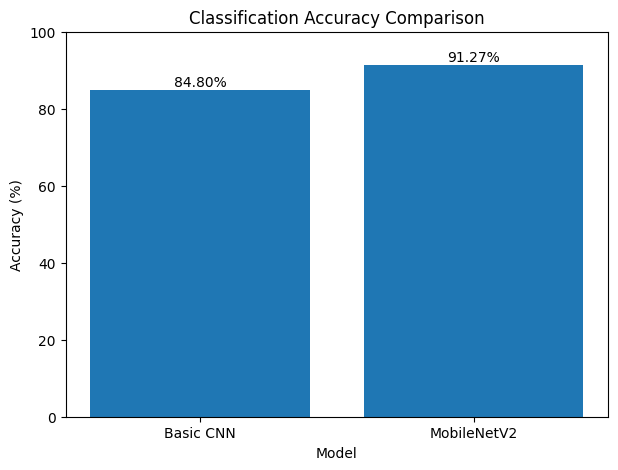

In [ ]:
models_name = ['Basic CNN', 'MobileNetV2']
accuracy_values = [
    cnn_accuracy * 100,
    mobile_accuracy * 100
]

plt.figure(figsize=(7, 5))

bars = plt.bar(models_name, accuracy_values)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Classification Accuracy Comparison")
plt.ylim(0, 100)

for bar, value in zip(bars, accuracy_values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value:.2f}%",
        ha='center'
    )

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


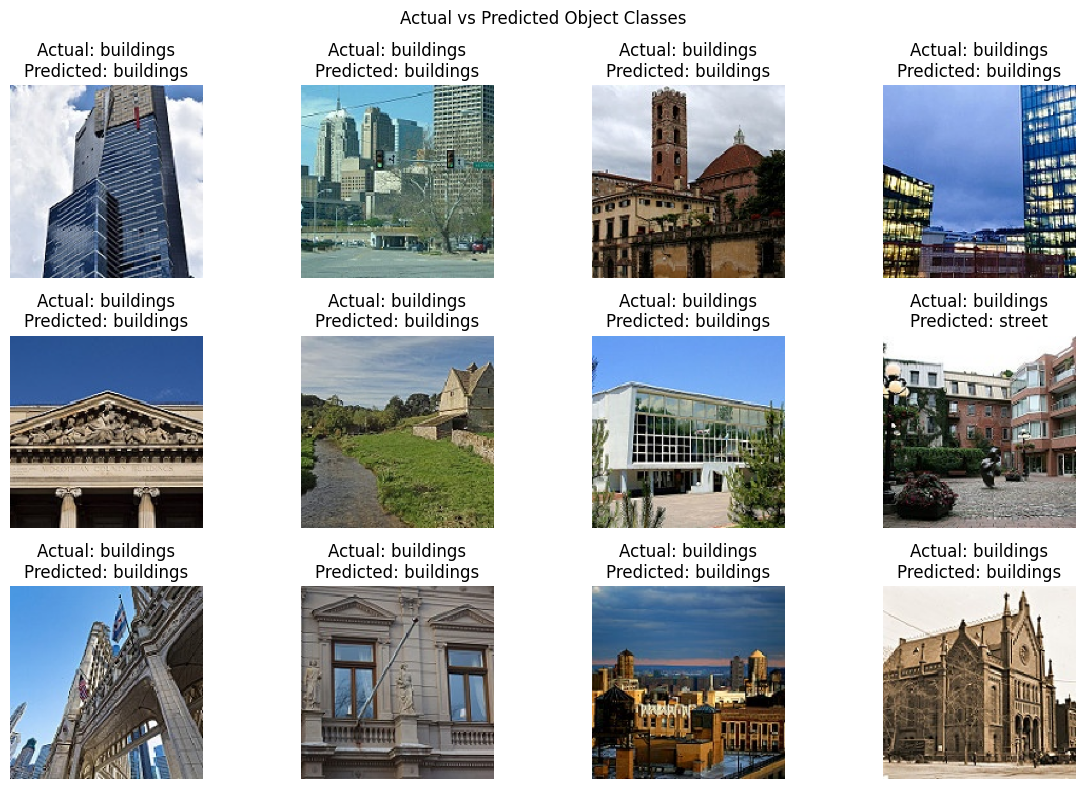

In [ ]:
mobile_test.reset()

images, labels = next(mobile_test)

predictions = mobile_model.predict(images)

plt.figure(figsize=(12, 8))

for i in range(12):

    actual = class_names[np.argmax(labels[i])]
    predicted = class_names[np.argmax(predictions[i])]

    plt.subplot(3, 4, i + 1)
    plt.imshow((images[i] + 1) / 2)

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.suptitle("Actual vs Predicted Object Classes")
plt.tight_layout()
plt.show()